In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from albumentations import HorizontalFlip, GridDistortion, OpticalDistortion, ChannelShuffle, CoarseDropout, CenterCrop, Crop, Rotate

In [3]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [24]:
def load_data(path, split=0.1):
     X = sorted(glob(os.path.join(path, "images", "*.jpg")))
     Y = sorted(glob(os.path.join(path, "masks", "*.png")))
     split_size = int(len(X) * split) 
     train_x, test_x = train_test_split(X, test_size=split_size, random_state=42)
     train_y, test_y = train_test_split(Y, test_size=split_size, random_state=42)
     return (train_x, train_y), (test_x, test_y)




In [27]:
data_path="/kaggle/input/person-segmentation/people_segmentation"

In [32]:
def augment_data(images, masks, save_path, augment=True):
    H = 512
    W = 512

    for x, y in tqdm(zip(images, masks), total=len(images)):
        name = x.split("/")[-1].split(".")[0]
        x = cv2.imread(x, cv2.IMREAD_COLOR)
        y = cv2.imread(y, cv2.IMREAD_COLOR)
        if augment == True:
            aug = HorizontalFlip(p=1.0)
            augmented = aug(image=x, mask=y)
            x1 = augmented["image"]
            y1 = augmented["mask"]

            x2 = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
            y2 = y

            aug = ChannelShuffle(p=1)
            augmented = aug(image=x, mask=y)
            x3 = augmented['image']
            y3 = augmented['mask']

            aug = CoarseDropout(p=1, min_holes=3, max_holes=10, max_height=32, max_width=32)
            augmented = aug(image=x, mask=y)
            x4 = augmented['image']
            y4 = augmented['mask']

            aug = Rotate(limit=45, p=1.0)
            augmented = aug(image=x, mask=y)
            x5 = augmented["image"]
            y5 = augmented["mask"]

            X = [x, x1, x2, x3, x4, x5]
            Y = [y, y1, y2, y3, y4, y5]

        else:
            X = [x]
            Y = [y]

        
        index = 0
        for i, m in zip(X, Y):
            try:
                """ Center Cropping """
                aug = CenterCrop(H, W, p=1.0)
                augmented = aug(image=i, mask=m)
                i = augmented["image"]
                m = augmented["mask"]

            except Exception as e:
                i = cv2.resize(i, (W, H))
                m = cv2.resize(m, (W, H))

            tmp_image_name = f"{name}_{index}.png"
            tmp_mask_name = f"{name}_{index}.png"

            image_path = os.path.join(save_path, "image", tmp_image_name)
            mask_path = os.path.join(save_path, "mask", tmp_image_name)

            cv2.imwrite(image_path, i)
            cv2.imwrite(mask_path, m)

            index += 1


In [33]:
    np.random.seed(42)

   
    
    (train_x, train_y), (test_x, test_y) = load_data(data_path)

    print(f"Train:\t {len(train_x)} - {len(train_y)}")
    print(f"Test:\t {len(test_x)} - {len(test_y)}")

    """ Create directories to save the augmented data """
    create_dir("new_data/train/image/")
    create_dir("new_data/train/mask/")
    create_dir("new_data/test/image/")
    create_dir("new_data/test/mask/")

    """ Data augmentation """
    augment_data(train_x, train_y, "new_data/train/", augment=True)
    augment_data(test_x, test_y, "new_data/test/", augment=False)

Train:	 5111 - 5111
Test:	 567 - 567


  0%|          | 0/5111 [00:00<?, ?it/s]/tmp/ipykernel_36/1681237269.py:23: UserWarning: Argument(s) 'min_holes, max_holes, max_height, max_width' are not valid for transform CoarseDropout
  aug = CoarseDropout(p=1, min_holes=3, max_holes=10, max_height=32, max_width=32)
100%|██████████| 567/567 [00:19<00:00, 29.19it/s]


In [35]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input

from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D, UpSampling2D, Reshape, Dense,Multiply

from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
import tensorflow as tf

In [37]:
def SqueezeAndExcite(inputs,ratio=8):
    b,_,_,channel=inputs.shape
    se_shape = (1, 1, channel)
    x=GlobalAveragePooling2D()(inputs)
    se = Reshape(se_shape)(x)
    dep1=Dense(channel//ratio,activation="relu",use_bias=False)(se)
    dep2=Dense(channel,activation="sigmoid",use_bias=False)(dep1)
    ans=Multiply()([inputs,dep2])
    return ans

In [57]:
def ASPP(inputs):
    shape=inputs.shape
    y1=AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)
    y1=Conv2D(256,1,padding="same",use_bias="False")(y1)
    y1=BatchNormalization()(y1)
    y1=Activation("relu")(y1)
    y1=UpSampling2D((shape[1], shape[2]))(y1)
    
    y2=Conv2D(256,1,use_bias="False",padding="same")(inputs)
    y2=BatchNormalization()(y2)
    y2=Activation("relu")(y2)

    y3=Conv2D(256,3,use_bias="False",padding="same",dilation_rate=6)(inputs)
    y3=BatchNormalization()(y3)
    y3=Activation("relu")(y3)

    y4=Conv2D(256,3,use_bias="False",padding="same",dilation_rate=12)(inputs)
    y4=BatchNormalization()(y4)
    y4=Activation("relu")(y4)

    y5=Conv2D(256,3,use_bias="False",padding="same",dilation_rate=18)(inputs)
    y5=BatchNormalization()(y5)
    y5=Activation("relu")(y5)

    y6=Concatenate()([y1,y2,y3,y4,y5])
    y6=Conv2D(256,1,padding="same",use_bias="False")(y6)
    y6=BatchNormalization()(y6)
    y6=Activation("relu")(y6)
     
    
    return y6 
    

In [41]:
def deeplabv3_plus(shape):
    inputs = Input(shape)
    encoder = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)
    image_features = encoder.get_layer("conv4_block6_out").output
    x_a =ASPP(image_features)
    x_a=UpSampling2D((4,4),interpolation="bilinear")(x_a)
    
    x_b = encoder.get_layer("conv2_block2_out").output
    X_b=Conv2D(filters=48,kernel_size=1, padding='same', use_bias=False)(x_b)
    x_b=BatchNormalization()(x_b)
    x_b=Activation("relu")(x_b)
    
    x=Concatenate()([x_a,x_b])
    x=Conv2D(256,3,use_bias="False",padding="same")(x)
    x=BatchNormalization()(x)
    x=Activation("relu")(x)
    x=SqueezeAndExcite(x)
    x = UpSampling2D((4, 4), interpolation="bilinear")(x)
    x = Conv2D(1, 1)(x)
    x = Activation("sigmoid")(x)
    model = Model(inputs, x)
    return model

    

In [45]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision

# from metrics import dice_loss, dice_coef, iou

In [46]:
H = 512
W = 512
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def shuffling(x, y):
    x, y = shuffle(x, y, random_state=42)
    return x, y

In [83]:
def load_data(path):
    x = sorted(glob(os.path.join(path, "image", "*png")))
    y = sorted(glob(os.path.join(path, "mask", "*png")))
    return x, y
def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (W, H))  # Resize to (512, 512)
    x = x / 255.0
    x = x.astype(np.float32)
    return x

def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (W, H))  # Resize to (512, 512)
    x = x.astype(np.float32)
    x = np.expand_dims(x, axis=-1)
    return x


In [84]:
def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(X, Y, batch=2):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.map(tf_parse)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(10)
    return dataset

In [85]:
if __name__ == "__main__":
    """ Seeding """
    np.random.seed(42)
    tf.random.set_seed(42)

    """ Directory for storing files """
    

    """ Hyperparameters """
    batch_size = 2
    lr = 1e-4
    num_epochs = 20
    
    csv_path = os.path.join("files", "data.csv")

    """ Dataset """
    dataset_path = "/kaggle/working/new_data"
    train_path = os.path.join(dataset_path, "train")
    valid_path = os.path.join(dataset_path, "test")

    train_x, train_y = load_data(train_path)
    train_x, train_y = shuffling(train_x, train_y)
    valid_x, valid_y = load_data(valid_path)

    print(f"Train: {len(train_x)} - {len(train_y)}")
    print(f"Valid: {len(valid_x)} - {len(valid_y)}")

    train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
    valid_dataset = tf_dataset(valid_x, valid_y, batch=batch_size)

Train: 30666 - 30666
Valid: 567 - 567


In [86]:
import tensorflow as tf

smooth = 1e-6  # Prevent division by zero

def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)
def iou(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [87]:
 model = deeplabv3_plus((H, W, 3))
model.compile(loss=dice_loss, optimizer=Adam(lr), metrics=[dice_coef, iou, Recall(), Precision()])

In [90]:
    model.fit(
        train_dataset,
        epochs=1,
        validation_data=valid_dataset,
        
    )

15333/15333 ━━━━━━━━━━━━━━━━━━━━ 2547s 166ms/step - dice_coef: 0.8850 - iou: 0.8092 - loss: 0.1150 - precision_2: 0.8908 - recall_2: 0.9100 - val_dice_coef: 0.8830 - val_iou: 0.8075 - val_loss: 0.1168 - val_precision_2: 0.8311 - val_recall_2: 0.9665


In [93]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score



In [94]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def save_results(image, mask, y_pred, save_image_path):
    ## i - m - yp - yp*i
    line = np.ones((H, 10, 3)) * 128

    mask = np.expand_dims(mask, axis=-1)    ## (512, 512, 1)
    mask = np.concatenate([mask, mask, mask], axis=-1)  ## (512, 512, 3)
    mask = mask * 255

    y_pred = np.expand_dims(y_pred, axis=-1)    ## (512, 512, 1)
    y_pred = np.concatenate([y_pred, y_pred, y_pred], axis=-1)  ## (512, 512, 3)

    masked_image = image * y_pred
    y_pred = y_pred * 255

    cat_images = np.concatenate([image, line, mask, line, y_pred, line, masked_image], axis=1)
    cv2.imwrite(save_image_path, cat_images)

if __name__ == "__main__":
    """ Seeding """
    np.random.seed(42)
    tf.random.set_seed(42)

    """ Directory for storing files """
    create_dir("results")

    """ Loading model """
    
    """ Load the dataset """
    dataset_path = "/kaggle/working/new_data"
    valid_path = os.path.join(dataset_path, "test")
    test_x, test_y = load_data(valid_path)
    print(f"Test: {len(test_x)} - {len(test_y)}")

    """ Evaluation and Prediction """
    SCORE = []
    for x, y in tqdm(zip(test_x, test_y), total=len(test_x)):
        """ Extract the name """
        name = x.split("/")[-1].split(".")[0]

        """ Reading the image """
        image = cv2.imread(x, cv2.IMREAD_COLOR)
        x = image/255.0
        x = np.expand_dims(x, axis=0)

        """ Reading the mask """
        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)

        """ Prediction """
        y_pred = model.predict(x)[0]
        y_pred = np.squeeze(y_pred, axis=-1)
        y_pred = y_pred > 0.5
        y_pred = y_pred.astype(np.int32)

        """ Saving the prediction """
        save_image_path = f"results/{name}.png"
        save_results(image, mask, y_pred, save_image_path)

        """ Flatten the array """
        mask = mask.flatten()
        y_pred = y_pred.flatten()

        """ Calculating the metrics values """
        acc_value = accuracy_score(mask, y_pred)
        f1_value = f1_score(mask, y_pred, labels=[0, 1], average="binary")
        jac_value = jaccard_score(mask, y_pred, labels=[0, 1], average="binary")
        recall_value = recall_score(mask, y_pred, labels=[0, 1], average="binary")
        precision_value = precision_score(mask, y_pred, labels=[0, 1], average="binary")
        SCORE.append([name, acc_value, f1_value, jac_value, recall_value, precision_value])

    """ Metrics values """
    score = [s[1:]for s in SCORE]
    score = np.mean(score, axis=0)
    print(f"Accuracy: {score[0]:0.5f}")
    print(f"F1: {score[1]:0.5f}")
    print(f"Jaccard: {score[2]:0.5f}")
    print(f"Recall: {score[3]:0.5f}")
    print(f"Precision: {score[4]:0.5f}")

    df = pd.DataFrame(SCORE, columns=["Image", "Accuracy", "F1", "Jaccard", "Recall", "Precision"])
    df.to_csv("files/score.csv")

Test: 567 - 567


  0%|          | 0/567 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


[ WARN:0@10542.545] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
  0%|          | 1/567 [00:04<46:31,  4.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


100%|█████████▉| 566/567 [04:22<00:00,  2.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


100%|██████████| 567/567 [04:22<00:00,  2.16it/s]

Accuracy: 0.91236
F1: 0.86434
Jaccard: 0.79772
Recall: 0.93034
Precision: 0.84667


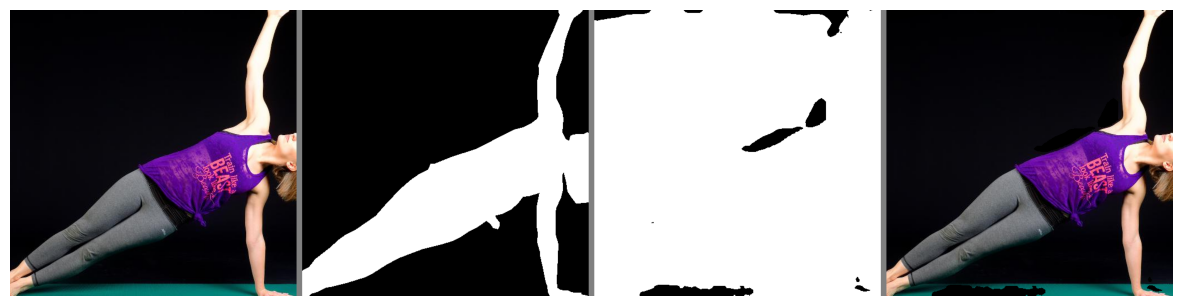

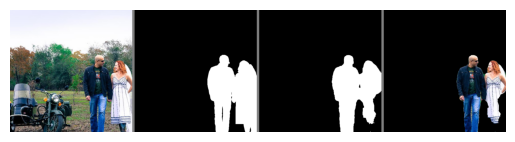

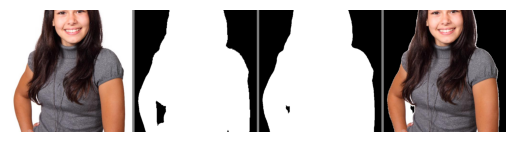

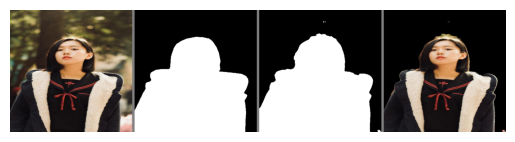

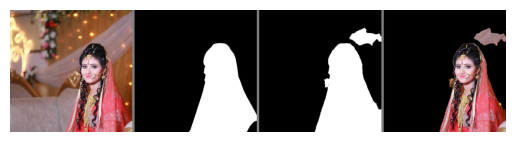

In [103]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Directory path
folder_path = "/kaggle/working/results/"

# Get all PNG files
image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".png")]

# Select 5 random images
random_images = random.sample(image_files, 5)

# Plot
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(random_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for matplotlib
  
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
    


